# Declaring Spot Random Variables

Every spot in the generative model carries a set of **random variables**: an
emergence time $t_{\rm ref}$, a longitude $\phi_{\rm ref}$, a latitude
$\lambda_{\rm ref}$, and morphology parameters (lifetime, growth/decay
timescales, amplitude). The analytic kernel is the expectation of the
single-spot covariance over *all* of them.

`SpotRandomVariables` makes that structure explicit: one declaration names
every random variable and its distribution, and each is routed to the
marginalization strategy that exploits its structure:

| random variable | distribution | marginalized by |
|---|---|---|
| $t_{\rm ref}$ (emergence time) | uniform (enforced) | closed form — the envelope autocorrelation $R_\Gamma(\tau)$ |
| $\phi_{\rm ref}$ (longitude) | uniform (enforced) | closed form — the harmonic $\lvert c_n\rvert^2$ structure |
| $\lambda_{\rm ref}$ (latitude) | `LatitudeDistributionFunction` on the model | latitude quadrature |
| morphology (lifetime, timescales, amplitude) | `SpotRandomVariables` declaration | reparameterized Gauss quadrature |

The payoff is **correlated** spot parameters: deterministic couplings
(`Derived`) tie several morphology parameters to shared latent variables. The
canonical example is the **Gnevyshev–Waldmeier relation** — sunspot peak area
scales with lifetime, $A \simeq W\,T$ — which couples spot *size* (and hence
photometric amplitude) to spot *lifetime*. An independent-parameter model
cannot express this; a declaration does it in three lines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from spotgp import (
    Derived,
    GaussianDistribution,
    GPSolver,
    Hyper,
    LogNormalLatent,
    PopulationSpotTerm,
    SpotEvolutionModel,
    SpotRandomVariables,
    SpotTerm,
    gnevyshev_waldmeier,
)

np.random.seed(42)

# Colorblind-safe colors (Okabe-Ito)
C_POP, C_POINT, C_ACCENT, C_GRAY = "#0072B2", "#D55E00", "#009E73", "#555555"

## 1. One declaration for every per-spot random variable

A morphology entry in the declaration dict may be:

- a plain **float** — the same fixed value for every spot (not fitted);
- a **`Hyper`** — the same value for every spot, fitted as a hyperparameter;
- a **`Latent`** (`LogNormalLatent`, `NormalLatent`, `UniformLatent`) —
  distributed across spots and marginalized over one quadrature dimension,
  with the distribution's hyperparameters fitted;
- a **`Derived`** — a deterministic function of previously declared entries.

The Gnevyshev–Waldmeier declaration uses a single latent — the lifetime
$T \sim \mathrm{LogNormal}$ with $\mathbb{E}[T] = \bar T$ — and derives
everything else from it. The envelope timescales scale with $T$ at a fixed
shape ratio $f$ (so lifetime $= \ell_{\rm spot} + 2\tau_{\rm spot} = T$), and
the amplitude follows the GW area–lifetime relation $\sigma_k \propto A
\propto T$. The GW constant $W$ cancels in the normalization — only the
$T$-dependence of the amplitude is observable in a kernel — so $\sigma_0$
keeps its interpretation as the amplitude of a mean-lifetime spot.

In [2]:
rv = SpotRandomVariables({
    # latent lifetime: T ~ LogNormal with E[T] = Tbar
    "T": LogNormalLatent(mean=Hyper("Tbar", 8.0, (0.5, 50.0)),
                         sigma=Hyper("sigma_T", 0.4, (0.01, 1.5)),
                         n_quad=16),
    "sigma0": Hyper("sigma0", 0.01, (1e-4, 1.0)),  # amplitude of a mean-lifetime spot
    "f": 0.2,                                      # rise/decay fraction (fixed)
    # Gnevyshev-Waldmeier couplings: everything follows the lifetime
    "lspot":    Derived(lambda p: (1.0 - 2.0 * p["f"]) * p["T"]),
    "tau_spot": Derived(lambda p: p["f"] * p["T"]),
    "sigma_k":  Derived(lambda p: p["sigma0"] * p["T"] / p["Tbar"]),
})

print("fitted hyperparameters:", rv.hyper_keys)
print("initial values:        ", rv.hyper0)
print("quadrature nodes:      ", rv.n_nodes)

fitted hyperparameters: ('Tbar', 'sigma_T', 'sigma0')
initial values:         [8.   0.4  0.01]
quadrature nodes:       16


The equivalent one-liner is `gnevyshev_waldmeier(Tbar=8.0, sigma_T=0.4,
sigma0=0.01, f=0.2)`.

### Guardrails

The uniformity of $t_{\rm ref}$ and $\phi_{\rm ref}$ is *load-bearing*: a
uniform emergence time is what makes the kernel stationary (enabling the
Toeplitz/banded solver fast path), and a uniform longitude is what produces
the clean harmonic structure. Declaring anything else fails loudly instead of
silently breaking stationarity:

In [3]:
try:
    SpotRandomVariables({"lspot": 2.0}, t_ref=GaussianDistribution(5.0, 1.0))
except NotImplementedError as err:
    print(err)

t_ref must be UniformEmergence, got GaussianDistribution(mu=5.0, sigma=1.0).  A non-uniform emergence-time density makes the kernel non-stationary and would silently break the Toeplitz/banded solver path; model activity cycles as an explicit modulation term instead.


## 2. One declaration, two consumers

The same declaration serves the **fitting side** and the **simulation side**:

- `resolve(phi)` returns quadrature nodes and weights for the marginalized
  kernel. The quadrature is *reparameterized*: base nodes are fixed
  (Gauss–Hermite for the log-normal latent), and the hyperparameters enter
  only through smooth transforms — so the kernel stays differentiable in
  $(\bar T, \sigma_T, \sigma_0)$ and JIT caches never invalidate during a fit.
- `sample(n)` draws per-spot parameter sets from the same distribution, for
  Monte-Carlo validation and lightcurve simulation.

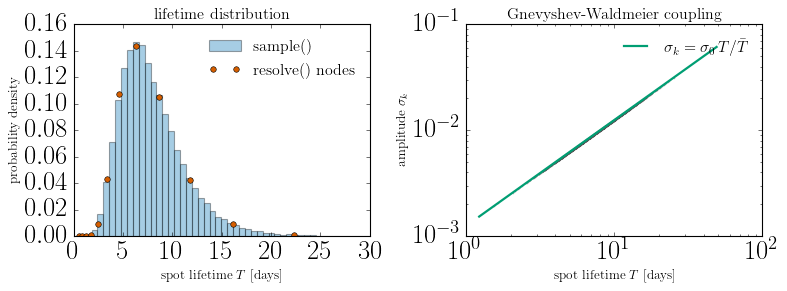

In [4]:
ns, w = rv.resolve(rv.hyper0)
T_nodes, weights = np.asarray(ns["T"]), np.asarray(w)

s = rv.sample(100_000, rng=np.random.default_rng(0))
T_samp = s["lspot"] + 2 * s["tau_spot"]   # lifetime = lspot + 2 tau_spot = T

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

ax = axes[0]
ax.hist(T_samp, bins=80, density=True, color=C_POP, alpha=0.35,
        label="sample()")
ax.plot(T_nodes, weights / np.gradient(T_nodes), "o", color=C_POINT,
        ms=5, label="resolve() nodes")
ax.set_xlabel("spot lifetime $T$ [days]")
ax.set_ylabel("probability density")
ax.set_xlim(0, 30)
ax.legend(frameon=False)
ax.set_title("lifetime distribution")

ax = axes[1]
sub = slice(0, 3000)
ax.loglog(T_samp[sub], s["sigma_k"][sub], ".", color=C_GRAY, ms=2,
          alpha=0.3)
Tline = np.linspace(T_samp.min(), T_samp.max(), 50)
ax.loglog(Tline, 0.01 * Tline / 8.0, color=C_ACCENT, lw=2,
          label=r"$\sigma_k = \sigma_0\, T/\bar{T}$")
ax.set_xlabel("spot lifetime $T$ [days]")
ax.set_ylabel(r"amplitude $\sigma_k$")
ax.legend(frameon=False)
ax.set_title("Gnevyshev-Waldmeier coupling")

fig.tight_layout()

## 3. The marginalized kernel: `PopulationSpotTerm`

`PopulationSpotTerm` evaluates

$$K(\tau) = V(\tau)\,\sum_m w_m\,\sigma_k^2(\theta_m)\,R_\Gamma(\tau;\theta_m),$$

where $\{\theta_m, w_m\}$ are the declaration's quadrature nodes. Geometry
(visibility, latitude band) is shared across the population exactly as in
`SharedVisibilitySpotSum` — the expensive latitude quadrature runs **once**
per kernel call — while each node adds only a closed-form envelope
autocorrelation. Marginalizing over the population is nearly free.

The fitted parameters are the star's geometry plus the distribution's
**hyperparameters** — not per-spot values. The model's own envelope values
are placeholders; the declaration replaces them node by node.

In [5]:
model = SpotEvolutionModel.from_hparam(
    dict(peq=10.0, kappa=0.2, inc=np.pi / 4,
         lspot=2.0, tau_spot=0.5, sigma_k=0.01))

term = PopulationSpotTerm(model, rv)
print("param_keys:", term.param_keys)
print("theta0:    ", np.round(term.theta0, 4))

param_keys: ('peq', 'kappa', 'inc', 'Tbar', 'sigma_T', 'sigma0')
theta0:     [10.      0.2     0.7854  8.      0.4     0.01  ]


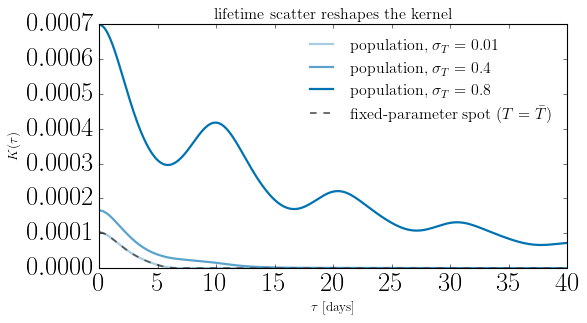

In [6]:
lag = jnp.linspace(0.0, 40.0, 400)
theta = np.array(term.theta0)
i_sT = term.param_keys.index("sigma_T")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for sT, alpha in zip([0.01, 0.4, 0.8], [0.35, 0.65, 1.0]):
    th = theta.copy()
    th[i_sT] = sT
    K = np.asarray(term.k_of_lag(jnp.asarray(th), lag))
    ax.plot(lag, K, color=C_POP, alpha=alpha, lw=2,
            label=rf"population, $\sigma_T = {sT}$")

point = SpotTerm(SpotEvolutionModel.from_hparam(
    dict(peq=10.0, kappa=0.2, inc=np.pi / 4,
         lspot=0.6 * 8.0, tau_spot=0.2 * 8.0, sigma_k=0.01)))
K_point = np.asarray(point.k_of_lag(jnp.asarray(point.theta0), lag))
ax.plot(lag, K_point, "--", color=C_GRAY, lw=1.5,
        label=r"fixed-parameter spot ($T = \bar{T}$)")

ax.set_xlabel(r"$\tau$ [days]")
ax.set_ylabel(r"$K(\tau)$")
ax.legend(frameon=False)
ax.set_title("lifetime scatter reshapes the kernel")
fig.tight_layout()

At $\sigma_T \to 0$ the population collapses onto the fixed-parameter kernel
(the two lowest curves overlap). As the lifetime scatter grows, two things
happen, and both are *observable* signatures of the GW coupling:

1. **$k(0)$ rises steeply.** Each spot contributes
   $\sigma_k^2\,R_\Gamma(0) \propto T^3$ — amplitude$^2 \propto T^2$ from the
   GW relation, envelope power $R_\Gamma(0) \propto T$ — so the zero-lag
   variance is boosted by $\mathbb{E}[(T/\bar T)^3] = e^{3\sigma_T^2}$
   ($\approx 7\times$ at $\sigma_T = 0.8$).
2. **Rotational harmonics reappear.** The bumps at multiples of
   $P_{\rm eq} = 10$ d exist because the $T^3$ weighting hands the covariance
   to long-lived spots that survive many rotations — periodic structure that
   a fixed mean-lifetime model washes out entirely.

Long-lived spots dominate the covariance far out of proportion to their
number; that is the effect an independent-parameter model cannot express.

## 4. Validation against Monte Carlo

The marginalized kernel is $\mathbb{E}_p[K_{\rm spot}]$, so the quadrature
should agree with a brute-force average of fixed-parameter kernels over
`sample()` draws — same declaration, no shared code path:

max |MC - quadrature| / k(0) = 0.011
MC standard error at tau=0   = 0.043


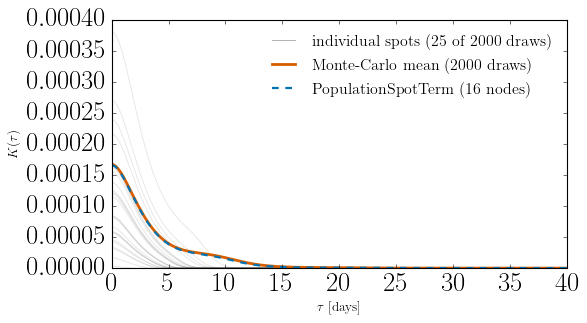

In [7]:
n_mc = 2000
samp = rv.sample(n_mc, rng=np.random.default_rng(1))
geom = np.tile(theta[:3], (n_mc, 1))
thetas = np.column_stack(
    [geom, samp["lspot"], samp["tau_spot"], samp["sigma_k"]])

point_term = SpotTerm(model)
K_draws = np.asarray(jax.vmap(
    lambda th: point_term.k_of_lag(th, lag))(jnp.asarray(thetas)))
K_pop = np.asarray(term.k_of_lag(jnp.asarray(term.theta0), lag))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(lag, K_draws[:25].T, color=C_GRAY, alpha=0.15, lw=0.8)
ax.plot([], [], color=C_GRAY, alpha=0.5, lw=0.8,
        label=f"individual spots (25 of {n_mc} draws)")
ax.plot(lag, K_draws.mean(axis=0), color=C_POINT, lw=2.5,
        label=f"Monte-Carlo mean ({n_mc} draws)")
ax.plot(lag, K_pop, "--", color=C_POP, lw=2,
        label=f"PopulationSpotTerm ({rv.n_nodes} nodes)")
ax.set_xlabel(r"$\tau$ [days]")
ax.set_ylabel(r"$K(\tau)$")
ax.legend(frameon=False)
fig.tight_layout()

# The per-draw covariance is heavy-tailed (sigma_k^2 R ~ T^2), so the
# honest MC standard error comes from the draws themselves.
dev = np.max(np.abs(K_draws.mean(axis=0) - K_pop)) / K_pop[0]
mc_se = np.std(K_draws[:, 0]) / np.sqrt(n_mc) / K_pop[0]
print(f"max |MC - quadrature| / k(0) = {dev:.3f}")
print(f"MC standard error at tau=0   = {mc_se:.3f}")

## 5. Marginalized power spectrum

`psd` returns the quadrature-weighted sum of per-node power spectra. The
lifetime distribution boosts the low-frequency plateau (the $T^3$-weighted
long-lived spots again) and softens the envelope's high-frequency sidelobe
structure relative to a single lifetime — frequency-domain diagnostics that
help separate $\sigma_T$ from $\bar T$ when fitting:

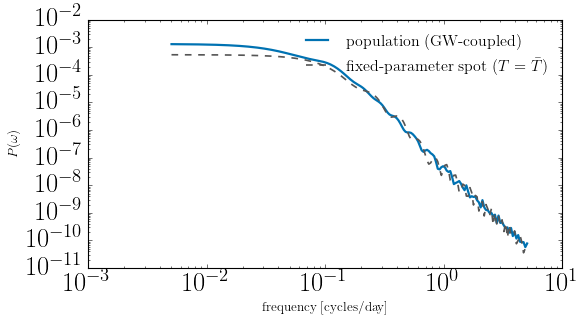

In [8]:
omega = np.logspace(-1.5, 1.5, 200)
freq, P_pop = term.psd(omega)
freq, P_point = point.psd(omega)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.loglog(freq, P_pop, color=C_POP, lw=2, label="population (GW-coupled)")
ax.loglog(freq, P_point, "--", color=C_GRAY, lw=1.5,
          label=r"fixed-parameter spot ($T = \bar{T}$)")
ax.set_xlabel("frequency [cycles/day]")
ax.set_ylabel(r"$P(\omega)$")
ax.legend(frameon=False)
fig.tight_layout()

## 6. Fitting the hyperparameters

The term drops into `GPSolver` unchanged — same flat parameter vector, same
Toeplitz/banded fast path, same composition with other terms via
`KernelSum`. Gradients flow through the quadrature to the population
hyperparameters:

In [9]:
rng = np.random.default_rng(3)
x = np.linspace(0.0, 25.0, 200)
y = (1.0 + 0.01 * np.sin(2 * np.pi * x / 10.0)
     + 0.002 * rng.standard_normal(x.size))
yerr = 0.002 * np.ones(x.size)

gw = gnevyshev_waldmeier(Tbar=8.0, sigma_T=0.4, sigma0=0.01, f=0.2)
gp = GPSolver(x, y, yerr, PopulationSpotTerm(model, gw),
              matrix_solver="cholesky_full")

print(f"log L(theta0) = {float(gp.log_likelihood_fn(gp.theta0)):.2f}\n")
val, grad = gp.value_and_grad_log_posterior(gp.theta0)
for k, g in zip(gp.param_keys, np.asarray(grad)):
    print(f"  d logP / d {k:8s} = {g: .3e}")

log L(theta0) = 909.87



  d logP / d peq      =  7.397e-01
  d logP / d kappa    =  1.296e+00
  d logP / d inc      =  9.379e-01
  d logP / d Tbar     =  6.841e-01
  d logP / d sigma_T  = -2.213e+00
  d logP / d sigma0   = -2.032e+03


Every hyperparameter — including the lifetime scatter $\sigma_T$ — has a
finite, nonzero gradient, so the population structure is fit directly by
MAP optimization or MCMC exactly like any other kernel parameter.

## Where to go next

- **Custom couplings** — any `Derived` over shared latents works, and
  multiple latents build a tensor-product quadrature automatically. Scatter
  *around* the GW relation is one extra latent, a log-normal multiplier
  with unit mean:
  `"eps": LogNormalLatent(mean=1.0, sigma=Hyper("sigma_A", 0.3))` and
  `"sigma_k": Derived(lambda p: p["sigma0"] * p["T"] / p["Tbar"] * p["eps"])`.
- **`fit_f=True`** promotes the trapezoid shape ratio to a fitted hyper.
- **Bounds** declared on each `Hyper` become the term's `default_bounds`,
  and participate in the banded solver's conservative bandwidth estimate
  (`bandwidth_support` resolves the declaration at the corners of the
  hyperparameter prior box).
- **What is deliberately rejected**: non-uniform $t_{\rm ref}$ (activity
  cycles are a non-stationary modulation, not a parameter distribution),
  non-uniform $\phi_{\rm ref}$ (active longitudes phase-lock the process),
  and latitude-correlated morphology (does not factor out of the latitude
  quadrature). Each raises with an explanation rather than degrading
  silently.
- See the [composite kernels tutorial](composite_kernels.ipynb) for
  combining a `PopulationSpotTerm` with granulation (`SHOTerm`) and other
  components in one `KernelSum`.